# 01 — Data Exploration
## Cedar Creek Fire, Eugene OR — Aug–Sep 2022

This notebook loads all three raw data sources, checks coverage, and produces
an initial visual overview before any cleaning or merging.

**Sources:**
- PurpleAir — 57 community sensors, 60-min averages
- NOAA ASOS KEUG — sub-hourly METAR observations, Eugene airport
- LRAPA — hourly regulatory PM2.5, 7 Lane County stations

In [1]:
import sys
sys.path.append("../src")

from data_loader import PurpleAirLoader, NOAALoader, LRAPALoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 1. PurpleAir Data

In [2]:
pa_loader = PurpleAirLoader(data_dir="../data/raw/purpleair")
pa_raw = pa_loader.load_all_sensors_in_directory()

print(f"\nShape:    {pa_raw.shape}")
print(f"Sensors:  {pa_raw['sensor_id'].nunique()}")
print(f"Columns:  {pa_raw.columns.tolist()}")
print(f"Date range: {pa_raw['timestamp'].min()} → {pa_raw['timestamp'].max()}")
pa_raw.head(3)

Found 58 sensor data files

Shape:    (62526, 10)
Sensors:  50
Columns:  ['time_stamp', 'humidity_a', 'temperature_a', 'pressure_a', 'pm2.5_alt_a', 'pm2.5_atm_a', 'pm2.5_cf_1_a', 'pm2.5_cf_1_b', 'timestamp', 'sensor_id']
Date range: 2022-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-07:00


/Users/dylanmurphy/Library/CloudStorage/OneDrive-UniversityOfOregon/Thesis/PM2.5-weather/notebooks/../src/data_loader.py:91: UserWarning: Failed to load ../data/raw/purpleair/PurpleAir Download 5-5-2026/ 2022-08-01 2022-09-30 60-Minute Average.csv: No columns to parse from file
  warnings.warn(f"Failed to load {filepath}: {e}")


,time_stamp,humidity_a,temperature_a,pressure_a,pm2.5_alt_a,pm2.5_atm_a,pm2.5_cf_1_a,pm2.5_cf_1_b,timestamp,sensor_id
0,2022-07-31 17:00:00-07:00,36.0,95.0,988.47,5.1,6.7,6.7,7.1,2022-07-31 17:00:00-07:00,143614
1,2022-07-31 18:00:00-07:00,40.0,91.0,988.02,5.4,7.2,7.2,7.4,2022-07-31 18:00:00-07:00,143614
2,2022-07-31 19:00:00-07:00,42.0,89.0,988.33,5.2,6.9,6.9,7.1,2022-07-31 19:00:00-07:00,143614


In [3]:
# Per-sensor coverage: how many hourly readings does each sensor have?
expected_hours = 61 * 24  # Aug 1 – Sep 30
sensor_counts = pa_raw.groupby('sensor_id')['timestamp'].count().sort_values()
coverage_pct = (sensor_counts / expected_hours * 100).round(1)

print(f"Expected readings per sensor: {expected_hours}")
print(f"\nCoverage (%):")
print(coverage_pct.to_string())
print(f"\nMedian coverage: {coverage_pct.median():.1f}%")
print(f"Sensors with >90% coverage: {(coverage_pct > 90).sum()}")

Expected readings per sensor: 1464

Coverage (%):
sensor_id
155233     8.2
155127    13.0
154407    13.4
115693    29.5
85073     31.4
120349    40.0
117013    45.6
76761     46.1
108690    67.6
153576    82.0
122007    83.8
35277     87.5
72495     93.0
120809    94.9
5432      96.2
10642     97.3
109176    97.3
119025    97.9
137786    98.0
34799     98.1
84517     98.1
86181     98.2
143614    98.3
107766    98.3
38823     98.3
146502    98.4
10614     98.4
81867     98.4
78825     98.4
78281     98.4
109468    98.4
111872    98.4
65221     98.4
57669     98.4
56961     98.4
114419    98.4
3904      98.4
146152    98.4
38749     98.4
114523    98.4
34927     98.4
115983    98.4
34195     98.4
3419      98.4
2572      98.4
119947    98.4
126471    98.4
85283     98.4
3911      98.4
101485    98.4

Median coverage: 98.3%
Sensors with >90% coverage: 38


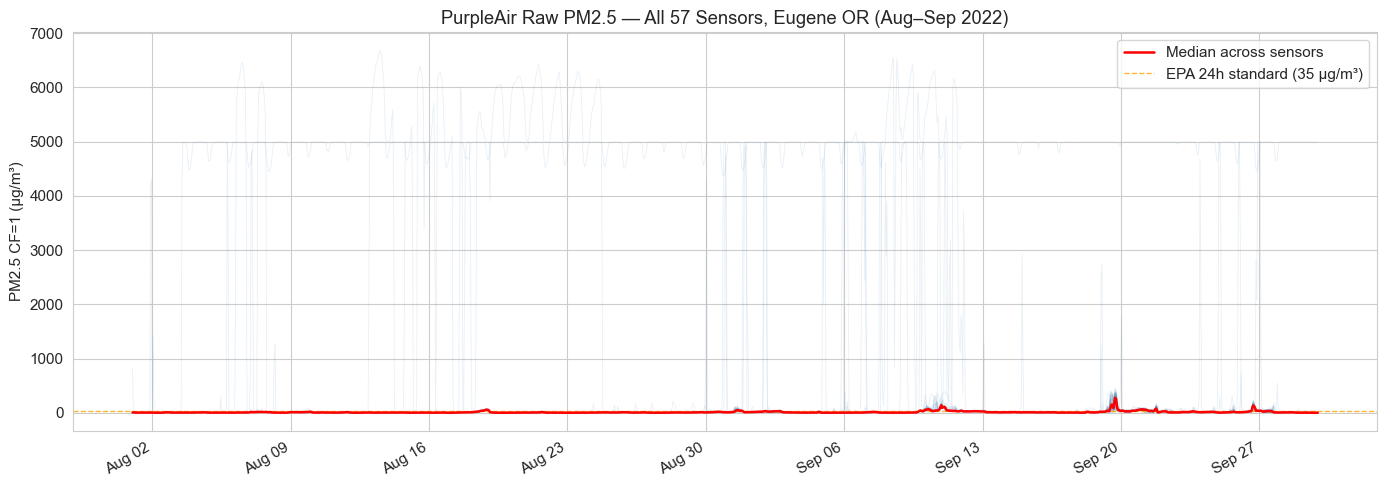

In [4]:
# Raw PM2.5 time series — all sensors (gray) + median (red)
fig, ax = plt.subplots(figsize=(14, 5))

for sid, grp in pa_raw.groupby('sensor_id'):
    ax.plot(grp['timestamp'], grp['pm2.5_cf_1_a'],
            alpha=0.12, color='steelblue', linewidth=0.6)

median_ts = pa_raw.groupby('timestamp')['pm2.5_cf_1_a'].median()
ax.plot(median_ts.index, median_ts.values,
        color='red', linewidth=1.8, label='Median across sensors', zorder=5)

ax.axhline(35, color='orange', linestyle='--', linewidth=1, alpha=0.8, label='EPA 24h standard (35 µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('PM2.5 CF=1 (µg/m³)')
ax.set_title('PurpleAir Raw PM2.5 — All 57 Sensors, Eugene OR (Aug–Sep 2022)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_pa_raw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. NOAA Weather Data (KEUG — Eugene Airport)

In [5]:
noaa_loader = NOAALoader(data_dir="../data/raw/noaa")
noaa_raw = noaa_loader.load_all_weather_data()

# Keep only the EUG station (Eugene airport ASOS); drop the 77S auxiliary station
noaa_eug = noaa_raw[noaa_raw['station'] == 'EUG'].copy()
print(f"NOAA raw records (all stations): {len(noaa_raw)}")
print(f"NOAA EUG records:                {len(noaa_eug)}")
print(f"Date range: {noaa_eug['timestamp'].min()} → {noaa_eug['timestamp'].max()}")
print(f"\nWeather columns available: {[c for c in noaa_eug.columns if c not in ['station','valid','timestamp','metar']]}")
noaa_eug[['timestamp','temperature_f','humidity','wind_speed_mph','wind_direction','pressure_hpa']].head(5)

Detected data source: metar
Detected data source: metar
NOAA raw records (all stations): 18592
NOAA EUG records:                5591
Date range: 2020-08-14 17:54:00-07:00 → 2022-11-29 15:54:00-08:00

Weather columns available: ['tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'p01i', 'alti', 'mslp', 'vsby', 'gust', 'skyc1', 'skyc2', 'skyc3', 'skyc4', 'skyl1', 'skyl2', 'skyl3', 'skyl4', 'wxcodes', 'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr', 'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time', 'feel', 'snowdepth', 'temperature_f', 'temperature_c', 'dewpoint_f', 'dewpoint_c', 'humidity', 'pressure_hpa', 'wind_speed_knots', 'wind_speed_mph', 'wind_speed_mps', 'wind_direction', 'precipitation_in', 'precipitation_mm', 'visibility_miles', 'visibility_km']


,timestamp,temperature_f,humidity,wind_speed_mph,wind_direction,pressure_hpa
2,2022-07-31 17:54:00-07:00,90.0,42.20,9.20624,240.0,1011.3
6,2022-07-31 18:54:00-07:00,87.0,49.60,14.96014,210.0,1011.3
10,2022-07-31 19:54:00-07:00,82.0,50.97,12.65858,240.0,1011.9
14,2022-07-31 20:54:00-07:00,76.0,58.04,14.96014,240.0,1012.2
18,2022-07-31 21:54:00-07:00,73.0,59.12,12.65858,210.0,1012.9


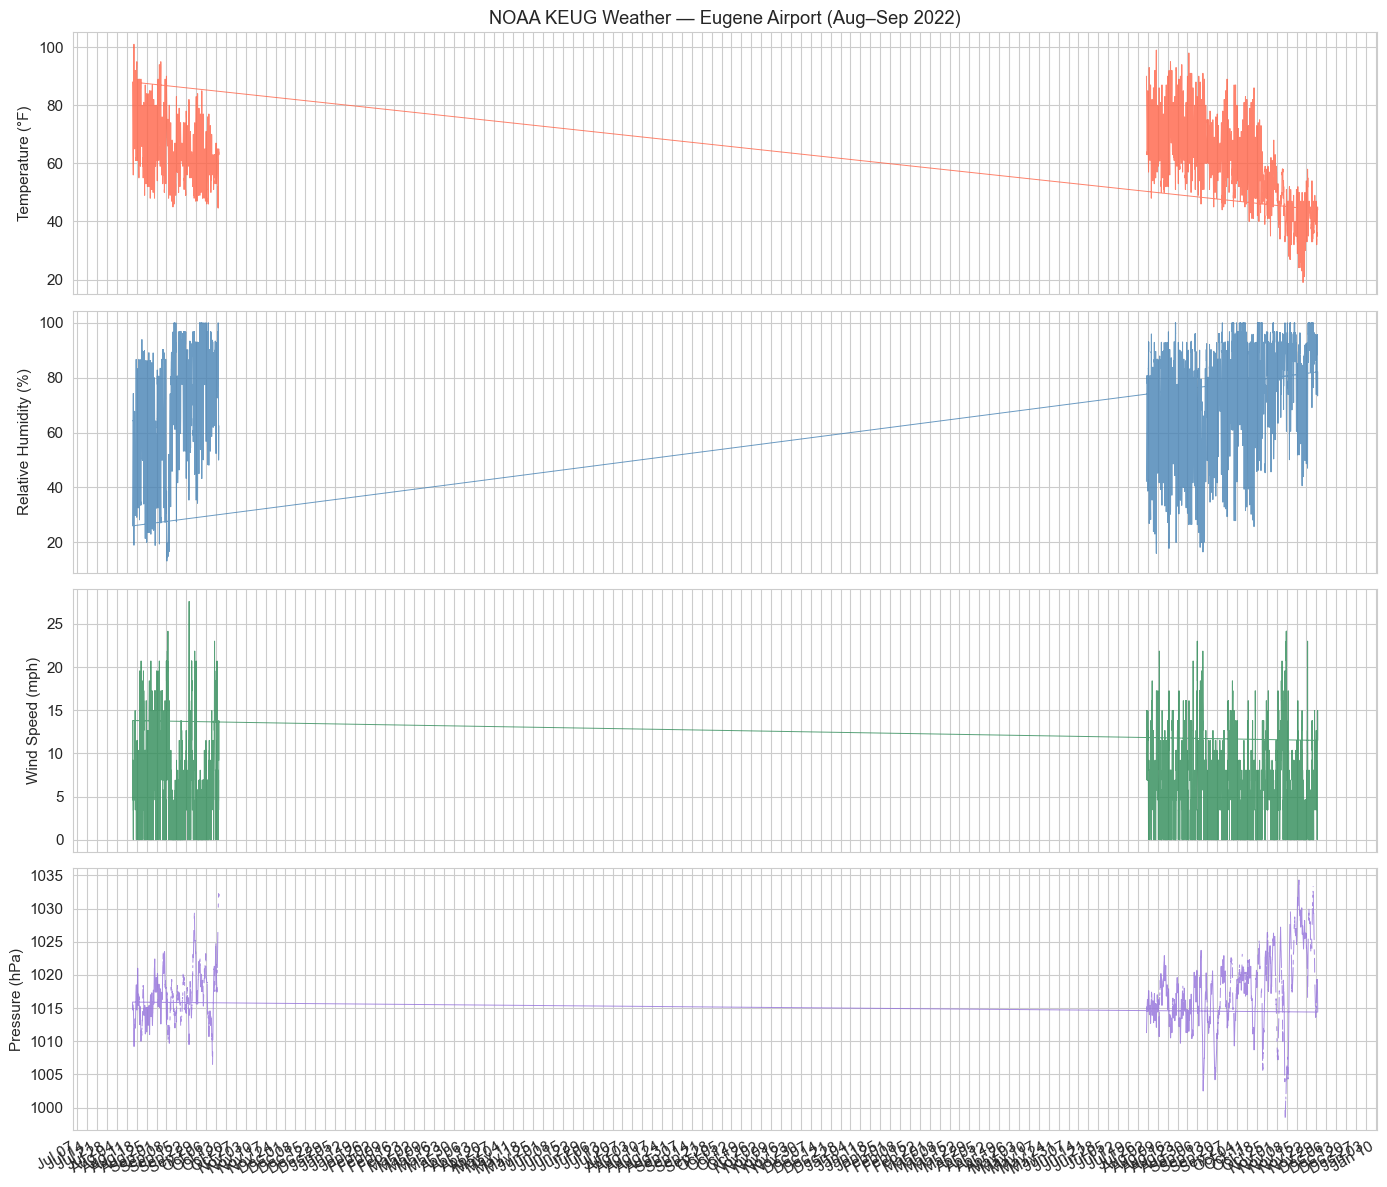

In [6]:
# NOAA weather overview — four-panel time series
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
weather_vars = [
    ('temperature_f', 'Temperature (°F)', 'tomato'),
    ('humidity',      'Relative Humidity (%)', 'steelblue'),
    ('wind_speed_mph','Wind Speed (mph)', 'seagreen'),
    ('pressure_hpa',  'Pressure (hPa)', 'mediumpurple'),
]
for ax, (col, label, color) in zip(axes, weather_vars):
    if col in noaa_eug.columns:
        ax.plot(noaa_eug['timestamp'], noaa_eug[col], color=color, linewidth=0.7, alpha=0.8)
        ax.set_ylabel(label)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0].set_title('NOAA KEUG Weather — Eugene Airport (Aug–Sep 2022)')
plt.tight_layout()
plt.savefig('../data/processed/fig_noaa_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. LRAPA Regulatory Data

In [7]:
lrapa_loader = LRAPALoader(data_dir="../data/raw/lrapa")
lrapa_raw = lrapa_loader.load_all_lrapa_data()
print(lrapa_loader.get_data_summary(lrapa_raw))
lrapa_raw.head(3)

Loaded 1464 LRAPA records from LRAPAHourlyDataExport05052026-2.xlsx
Date range: 2022-08-01 02:00:00-07:00 → 2022-10-01 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
{'n_records': 1464, 'date_range': (Timestamp('2022-08-01 02:00:00-0700', tz='America/Los_Angeles'), Timestamp('2022-10-01 01:00:00-0700', tz='America/Los_Angeles')), 'columns': ['pm2.5_cottage_grove', 'pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_florence', 'pm2.5_oakridge', 'pm2.5_santa_clara', 'pm2.5_springfield', 'timestamp', 'pm2.5_lrapa_regulatory'], 'missing': {'pm2.5_cottage_grove': 3, 'pm2.5_amazon_park': 3, 'pm2.5_highway_99': 1, 'pm2.5_florence': 0, 'pm2.5_oakridge': 1, 'pm2.5_santa_clara': 1, 'pm2.5_springfield': 0, 'timestamp': 0, 'pm2.5_lrapa_regulatory': 0}, 'pm2.5_regulatory_stats': {'count': 1464.0, 'mean': 6.249180327868852, 'std': 6.64651309583233, 'min': 0.95, '25%': 2.8118749999999997, '50%': 3.865, '75%': 7.07625, 'max

,pm2.5_cottage_grove,pm2.5_amazon_park,pm2.5_highway_99,pm2.5_florence,pm2.5_oakridge,pm2.5_santa_clara,pm2.5_springfield,timestamp,pm2.5_lrapa_regulatory
0,3.48,3.49,2.79,2.01,6.94,2.23,3.57,2022-08-01 02:00:00-07:00,3.0200
1,3.09,2.97,2.67,2.16,6.61,2.03,3.04,2022-08-01 03:00:00-07:00,2.6775
2,3.03,2.98,2.57,3.52,4.33,2.15,3.44,2022-08-01 04:00:00-07:00,2.7850


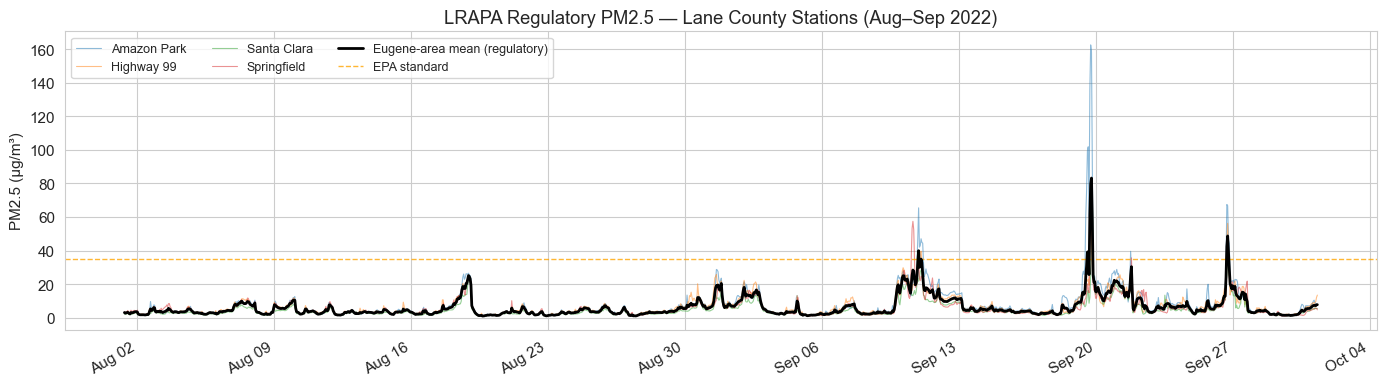

In [8]:
# LRAPA all stations + regulatory mean
station_cols = ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
station_cols = [c for c in station_cols if c in lrapa_raw.columns]

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for col, color in zip(station_cols, colors):
    ax.plot(lrapa_raw['timestamp'], lrapa_raw[col],
            alpha=0.5, linewidth=0.8, color=color, label=col.replace('pm2.5_', '').replace('_', ' ').title())

ax.plot(lrapa_raw['timestamp'], lrapa_raw['pm2.5_lrapa_regulatory'],
        color='black', linewidth=2, label='Eugene-area mean (regulatory)', zorder=5)
ax.axhline(35, color='orange', linestyle='--', linewidth=1, alpha=0.8, label='EPA standard')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('LRAPA Regulatory PM2.5 — Lane County Stations (Aug–Sep 2022)')
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig('../data/processed/fig_lrapa_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Missing Data Summary

In [9]:
print("=== Missing Data Summary ===")
print(f"\nPurpleAir (per key column):")
for col in ['pm2.5_cf_1_a', 'pm2.5_cf_1_b', 'pm2.5_alt_a', 'humidity_a']:
    if col in pa_raw.columns:
        pct = pa_raw[col].isna().mean() * 100
        print(f"  {col:25s}: {pct:.1f}% missing")

print(f"\nNOAA EUG (per key column):")
for col in ['temperature_f', 'humidity', 'wind_speed_mph', 'pressure_hpa']:
    if col in noaa_eug.columns:
        pct = noaa_eug[col].isna().mean() * 100
        print(f"  {col:25s}: {pct:.1f}% missing")

print(f"\nLRAPA regulatory:")
pct = lrapa_raw['pm2.5_lrapa_regulatory'].isna().mean() * 100
print(f"  pm2.5_lrapa_regulatory  : {pct:.1f}% missing")

=== Missing Data Summary ===

PurpleAir (per key column):
  pm2.5_cf_1_a             : 0.0% missing
  pm2.5_cf_1_b             : 0.0% missing
  pm2.5_alt_a              : 0.0% missing
  humidity_a               : 2.9% missing

NOAA EUG (per key column):
  temperature_f            : 0.1% missing
  humidity                 : 0.1% missing
  wind_speed_mph           : 0.2% missing
  pressure_hpa             : 22.1% missing

LRAPA regulatory:
  pm2.5_lrapa_regulatory  : 0.0% missing
